# SVG pipeline

### Loading data

In [1]:
"""base_pipeline.ipynb

Comments : Primary preprocessing and validation pipeline for the CMsiRNA dataset
Date     : 2026/06/13
"""

from utils.pipeline import SiRNADataPipeline
from utils.splitter import GroupKFoldLeakPerGroup
from utils.merge_historic_data import load_merged_dataset

# primary CMsiRNA dataset stacked with the historic dataset
raw_df = load_merged_dataset(r"path to cmsirna dataset",
                             r"path to historic dataset")
raw_df.head()


loaded 3515 historic rows
merged 43153 CMsiRNA and 3515 historic rows into 46668


,ID,patent_ID,Authorization_status,Accession_number,gene_target_symbol_name,Gene_ID,The_name_of_double_helix,Antisense_seqence,length_anti_sense_strand,Modifications_AntiSense_strand,...,Modification_locations_Sense_strand,position_Sense_strand,Inhibition,SD,Cell_Type,Concentration,Time_of_administration,Title,Modifications_AntiSense_strand_3_5,mRNA
0,001-01-01-00001-100n-48h-88.00,CN107365771B,Unknown Status,NM_001330729.2,CTNNB1,1499.0,D1,UUAGAAAGCUGAUGGACCAUAACUG,25.0,UUAGAAAGCUGAUGGACCAUAACUG,...,Sugar,"1,2,3,4,5,6,7,19,20,21,22,23,24,25",88.0,NaN,Hela,100nM,48h,用于抑制CTNNB1靶基因mRNA表达的寡核酸分子及其成套组合物,GUCAAUACCAGGUAGUCGAAAGAUU,NaN
1,001-01-01-00002-100n-48h-90.00,CN107365771B,Unknown Status,NM_001330729.2,CTNNB1,1499.0,D2,UACAAUAGCAGACACCAUCUGAGGA,25.0,UACAAUAGCAGACACCAUCUGAGGA,...,Sugar,"1,2,3,4,5,6,7,19,20,21,22,23,24,25",90.0,NaN,Hela,100nM,48h,用于抑制CTNNB1靶基因mRNA表达的寡核酸分子及其成套组合物,AGGAGUCUACCACAGACGAUAACAU,NaN
2,001-01-01-00003-100n-48h-90.00,CN107365771B,Unknown Status,NM_001330729.2,CTNNB1,1499.0,D3,UGAACAAGACGUUGACUUGGAUCUG,25.0,UGAACAAGACGUUGACUUGGAUCUG,...,Sugar,"1,2,3,4,5,6,7,19,20,21,22,23,24,25",90.0,NaN,Hela,100nM,48h,用于抑制CTNNB1靶基因mRNA表达的寡核酸分子及其成套组合物,GUCUAGGUUCAGUUGCAGAACAAGU,NaN
3,001-01-01-00004-100n-48h-89.00,CN107365771B,Unknown Status,NM_001330729.2,CTNNB1,1499.0,D4,UUUAGUUGCAGCAUCUGAAAGAUUC,25.0,UUUAGUUGCAGCAUCUGAAAGAUUC,...,Sugar,"1,2,3,4,5,6,7,19,20,21,22,23,24,25",89.0,NaN,Hela,100nM,48h,用于抑制CTNNB1靶基因mRNA表达的寡核酸分子及其成套组合物,CUUAGAAAGUCUACGACGUUGAUUU,NaN
4,001-01-01-00005-100n-48h-87.00,CN107365771B,Unknown Status,NM_001330729.2,CTNNB1,1499.0,D5,UUUCGAAUCAAUCCAACAGUAGCCU,25.0,UUUCGAAUCAAUCCAACAGUAGCCU,...,Sugar,"1,2,3,4,5,6,7,19,20,21,22,23,24,25",87.0,NaN,Hela,100nM,48h,用于抑制CTNNB1靶基因mRNA表达的寡核酸分子及其成套组合物,UCCGAUGACAACCUAACUAAGCUUU,NaN


## Applying siRNADataPipeline

In [2]:
sirna_pipeline = SiRNADataPipeline(target_len=25, fetch_missing_mrna=False)

enriched_df = sirna_pipeline.enrich_dataset_with_encodings(
    raw_df,
    strict_cleaning=False,   # use MoreStrictDataCleaner
    add_mrna=True,          # set True if you need mRNA UTR columns
)

enriched_df.shape

Running qc and data cleaning
dropped 5756 rows (in-vivo 4233, mM 565, conc>200 797, cell 115, inhibition 102)
dropped 1749 rows with NaN concentration
dropped 2198 rows with a missing or >25 nt strand
imputed 6091 missing time rows (median 24.0h at or below 10 nM, 48.0h above)
dropped 6 columns: ['Modification_locations_Sense_strand', 'Modification_locations_Antisense_strand', 'Modifications_sense_strand', 'Modifications_AntiSense_strand_3_5', 'position_Antisense_strand', 'position_Sense_strand']
Mapping mRNA structural profiles
Error reading reference dataset: [Errno 2] No such file or directory: '/home/larsena8/software/fennec/src/fennec/support_files/train_data_v1.1.0_N=27742.csv'
Loaded 47 gene sequences from local cache
Loaded 0 gene sequences from reference CSV
Building gene -> mRNA mapping for 54 genes...
[1/54] Processing CTNNB1...
  Found in local cache (3074 bp)
[2/54] Processing INHBE...
  Found in local cache (2460 bp)
[3/54] Processing LPA...
  Found in local cache (6431 b

(35444, 38)

In [3]:
enriched_df.head()

,ID,patent_ID,Authorization_status,Accession_number,gene_target_symbol_name,Gene_ID,The_name_of_double_helix,Antisense_seqence,length_anti_sense_strand,Modifications_AntiSense_strand,...,Sense_Sequence_One_Hot,Antisense_Sequence_One_Hot,Sense_Acid_One_Hot,Sense_Sugar_One_Hot,Sense_Linker_One_Hot,Antisense_Acid_One_Hot,Antisense_Sugar_One_Hot,Antisense_Linker_One_Hot,Cell_Type_One_Hot,Concentration_norm
0,001-01-01-00001-100n-48h-88.00,CN107365771B,Unknown Status,NM_001330729.2,CTNNB1,1499.0,D1,UUAGAAAGCUGAUGGACCAUAACUG,25.0,UUAGAAAGCUGAUGGACCAUAACUG,...,"[[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0], [1.0, 0....","[[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 1....","[[1.0, 0.0, 0.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0....","[[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]...","[[1.0, 0.0, 0.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0....","[[1.0, 0.0, 0.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0....","[[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]...","[[1.0, 0.0, 0.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0....","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, ...",0.950412
1,001-01-01-00002-100n-48h-90.00,CN107365771B,Unknown Status,NM_001330729.2,CTNNB1,1499.0,D2,UACAAUAGCAGACACCAUCUGAGGA,25.0,UACAAUAGCAGACACCAUCUGAGGA,...,"[[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0....","[[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0], [1.0, 0....","[[1.0, 0.0, 0.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0....","[[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]...","[[1.0, 0.0, 0.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0....","[[1.0, 0.0, 0.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0....","[[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]...","[[1.0, 0.0, 0.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0....","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, ...",0.950412
2,001-01-01-00003-100n-48h-90.00,CN107365771B,Unknown Status,NM_001330729.2,CTNNB1,1499.0,D3,UGAACAAGACGUUGACUUGGAUCUG,25.0,UGAACAAGACGUUGACUUGGAUCUG,...,"[[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0], [1.0, 0....","[[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0....","[[1.0, 0.0, 0.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0....","[[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]...","[[1.0, 0.0, 0.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0....","[[1.0, 0.0, 0.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0....","[[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]...","[[1.0, 0.0, 0.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0....","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, ...",0.950412
3,001-01-01-00004-100n-48h-89.00,CN107365771B,Unknown Status,NM_001330729.2,CTNNB1,1499.0,D4,UUUAGUUGCAGCAUCUGAAAGAUUC,25.0,UUUAGUUGCAGCAUCUGAAAGAUUC,...,"[[0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0], [1.0, 0....","[[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 1....","[[1.0, 0.0, 0.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0....","[[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]...","[[1.0, 0.0, 0.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0....","[[1.0, 0.0, 0.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0....","[[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]...","[[1.0, 0.0, 0.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0....","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, ...",0.950412
4,001-01-01-00005-100n-48h-87.00,CN107365771B,Unknown Status,NM_001330729.2,CTNNB1,1499.0,D5,UUUCGAAUCAAUCCAACAGUAGCCU,25.0,UUUCGAAUCAAUCCAACAGUAGCCU,...,"[[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0....","[[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 1....","[[1.0, 0.0, 0.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0....","[[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]...","[[1.0, 0.0, 0.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0....","[[1.0, 0.0, 0.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0....","[[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]...","[[1.0, 0.0, 0.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0....","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, ...",0.950412


In [5]:
import numpy as np

X, groups, y = sirna_pipeline.prepare_for_classical_ml(enriched_df, target_column="Inhibition")
print(X.shape, y.shape, len(np.unique(groups)))

Feature matrix X shape: (35444, 1425), target y shape: (35444,)
(35444, 1425) (35444,) 54


In [6]:
def evaluate_overall(y_true, y_pred):
    spearman_r, spearman_p = spearmanr(y_true, y_pred)
    print(f"Spearman r = {spearman_r:.3f} (p={spearman_p:.2e})")
    return {"spearman": spearman_r}

def evaluate_by_group(y_true, y_pred, groups, group_name="gene"):
    results = []
    for g in np.unique(groups):
        mask = groups == g
        if mask.sum() < 5:
            continue
        r, _ = spearmanr(y_true[mask], y_pred[mask])
        results.append({"group": g, "spearman": r, "n": int(mask.sum())})

    results_df = pd.DataFrame(results).sort_values("spearman", ascending=False)
    print(f"\nSpearman by {group_name} (top 10):")
    print(results_df.head(10).to_string(index=False))
    print(f"\nSpearman by {group_name} (bottom 10):")
    print(results_df.tail(10).to_string(index=False))
    print(f"\nMean across {group_name}s: {results_df['spearman'].mean():.3f}")
    return results_df

In [17]:
from utils.sequence_encoding import SequenceEncoder

def build_feature_names(enriched_df, target_len=25):
    sugar_names = ["Unmodified", "2'-OMe", "2'-F", "2'-M", "2'-OHe", "2'-P", "Abasic", "2'-F-4'-Thio", "Unknown"]
    acid_names = ["RNA", "DNA", "GNA", "UNA", "LNA", "Unknown"]
    linker_names = ["Normal", "PS", "VP", "Both_VP_PS", "Phosphonate", "Unknown"]

    # get actual sequence column names from encoding map
    seq_encoder = SequenceEncoder(enriched_df, target_len=target_len)
    seq_encoder.build_encoding_map()
    seq_names = [k for k, v in sorted(seq_encoder.encoding_map.items(), key=lambda x: x[1])]

    names = ["Concentration_norm", "Time_hours"]

    # cell types — pull actual width from stored vector
    actual_cell_width = len(enriched_df["Cell_Type_One_Hot"].iloc[0])
    cell_types = sorted(enriched_df["Cell_Type"].dropna().unique())
    cell_type_names = [f"cell_{c}" for c in cell_types]
    if len(cell_type_names) < actual_cell_width:
        cell_type_names += [f"cell_unknown_{i}" for i in range(len(cell_type_names), actual_cell_width)]
    names += cell_type_names[:actual_cell_width]

    for strand in ["Sense", "Antisense"]:
        for pos in range(target_len):
            for base in seq_names:
                names.append(f"{strand}_seq_pos{pos}_{base}")

    for strand in ["Sense", "Antisense"]:
        for pos in range(target_len):
            for acid in acid_names:
                names.append(f"{strand}_acid_pos{pos}_{acid}")
        for pos in range(target_len):
            for sugar in sugar_names:
                names.append(f"{strand}_sugar_pos{pos}_{sugar}")
        for pos in range(target_len):
            for linker in linker_names:
                names.append(f"{strand}_linker_pos{pos}_{linker}")

    # mRNA alignment features
    for col in ["edit_distance", "target_site_pct"]:
        if col in enriched_df.columns:
            names.append(col)

    return names

## Modification counts across all siRNA positions; Antisense

In [9]:
import pandas as pd

def count_sugar_modifications(df, sugar_map):
    sugar_data = np.stack(df['Antisense_Sugar_One_Hot'].values)
    row_mods = np.any(sugar_data == 1, axis=1).astype(int)
    idx_to_sugar = {v: k for k, v in sugar_map.items()}

    counts = {}
    for i in range(len(sugar_map)):
        count = np.sum(sugar_data[:, :, i] == 1)
        counts[idx_to_sugar[i]] = count

    return pd.Series(counts)

sugar_map = {
    "Unmodified": 0, "2'-OMe": 1, "2'-F": 2, "2'-M": 3,
    "2'-OHe": 4, "2'-P": 5, "Abasic": 6, "2'-F-4'-Thio": 7, "Unknown": 8
}

modification_counts = count_sugar_modifications(enriched_df, sugar_map)
print("Modification counts across all siRNA positions:")
print(modification_counts)

Modification counts across all siRNA positions:
Unmodified       91604
2'-OMe          453891
2'-F            116918
2'-M                46
2'-OHe               0
2'-P              1085
Abasic               2
2'-F-4'-Thio       780
Unknown         147125
dtype: int64


## Modification counts across all siRNA positions; Sense

In [10]:
def count_sugar_modifications(df, sugar_map):
    sugar_data = np.stack(df['Sense_Sugar_One_Hot'].values)
    row_mods = np.any(sugar_data == 1, axis=1).astype(int)
    idx_to_sugar = {v: k for k, v in sugar_map.items()}

    counts = {}
    for i in range(len(sugar_map)):
        count = np.sum(sugar_data[:, :, i] == 1)
        counts[idx_to_sugar[i]] = count

    return pd.Series(counts)

sugar_map = {
    "Unmodified": 0, "2'-OMe": 1, "2'-F": 2, "2'-M": 3,
    "2'-OHe": 4, "2'-P": 5, "Abasic": 6, "2'-F-4'-Thio": 7, "Unknown": 8
}

modification_counts = count_sugar_modifications(enriched_df, sugar_map)
print("Modification counts across all siRNA positions:")
print(modification_counts)

Modification counts across all siRNA positions:
Unmodified       47595
2'-OMe          449991
2'-F            114372
2'-M                 0
2'-OHe            2626
2'-P                 0
Abasic               0
2'-F-4'-Thio         0
Unknown         147450
dtype: int64


## Split by gene

In [11]:
cv = GroupKFoldLeakPerGroup(n_splits=3, leak_n=30, random_state=42)

In [13]:
from cuml.svm import SVR
from cuml.preprocessing import StandardScaler
from scipy.stats import spearmanr
from tqdm import tqdm
import numpy as np

scores_spearman = []
all_preds = np.zeros(len(y))
all_test_idx = []

for fold_idx, (train_idx, test_idx) in tqdm(enumerate(cv.split(X, y, groups)),
                                            total=cv.get_n_splits(X, y, groups),
                                            desc="Evaluating SVR"):

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X[train_idx])
    X_test_scaled = scaler.transform(X[test_idx])

    model = SVR(kernel="rbf", C=100.0, gamma=0.001, epsilon=0.05)
    model.fit(X_train_scaled, y[train_idx])
    preds = model.predict(X_test_scaled)

    all_preds[test_idx] = preds
    all_test_idx.extend(test_idx)

    s_corr, _ = spearmanr(preds, y[test_idx])
    scores_spearman.append(s_corr)
    tqdm.write(f"Fold {fold_idx+1}: Spearman={s_corr:.4f}")

    np.save(f"preds_fold_{fold_idx+1}.npy", preds)
    np.save(f"test_idx_fold_{fold_idx+1}.npy", test_idx)

print(f"\nAverage Spearman: {np.mean(scores_spearman):.4f}")

all_test_idx = np.array(all_test_idx)
y_true_all = y[all_test_idx]
y_pred_all = all_preds[all_test_idx]

print("\n=== Overall (all folds combined) ===")
evaluate_overall(y_true_all, y_pred_all)

print("\n=== By Gene ===")
gene_results = evaluate_by_group(y_true_all, y_pred_all, groups[all_test_idx], "gene")

Evaluating SVR:  33%|███▎      | 1/3 [00:36<01:12, 36.48s/it]

Fold 1: Spearman=0.5141


Evaluating SVR:  67%|██████▋   | 2/3 [01:12<00:36, 36.31s/it]

Fold 2: Spearman=0.5464


Evaluating SVR: 100%|██████████| 3/3 [01:52<00:00, 37.52s/it]

Fold 3: Spearman=0.4642

Average Spearman: 0.5082

=== Overall (all folds combined) ===
Spearman r = 0.429 (p=0.00e+00)

=== By Gene ===

Spearman by gene (top 10):
 group  spearman  n
   NOG  0.806133 41
 UBE2N  0.766028 49
  UFC1  0.765647 40
UBE2D3  0.748453 48
 UBE2B  0.733577 49
CACNB1  0.728477 16
 UBE2C  0.727536 46
  MMP7  0.711416 53
UBE2V1  0.709141 44
  TC10  0.701600 37

Spearman by gene (bottom 10):
 group  spearman    n
  MAPT  0.485363  873
PNPLA3  0.473242 8445
 P2RX2  0.468530   47
  SOST  0.465263   45
 INHBE  0.402230 3479
UBE2J1  0.368421   19
   AGT  0.360849 4708
ICAM-1  0.303953   10
   PLN  0.279282  105
 MARC1  0.249562  379

Mean across genes: 0.582


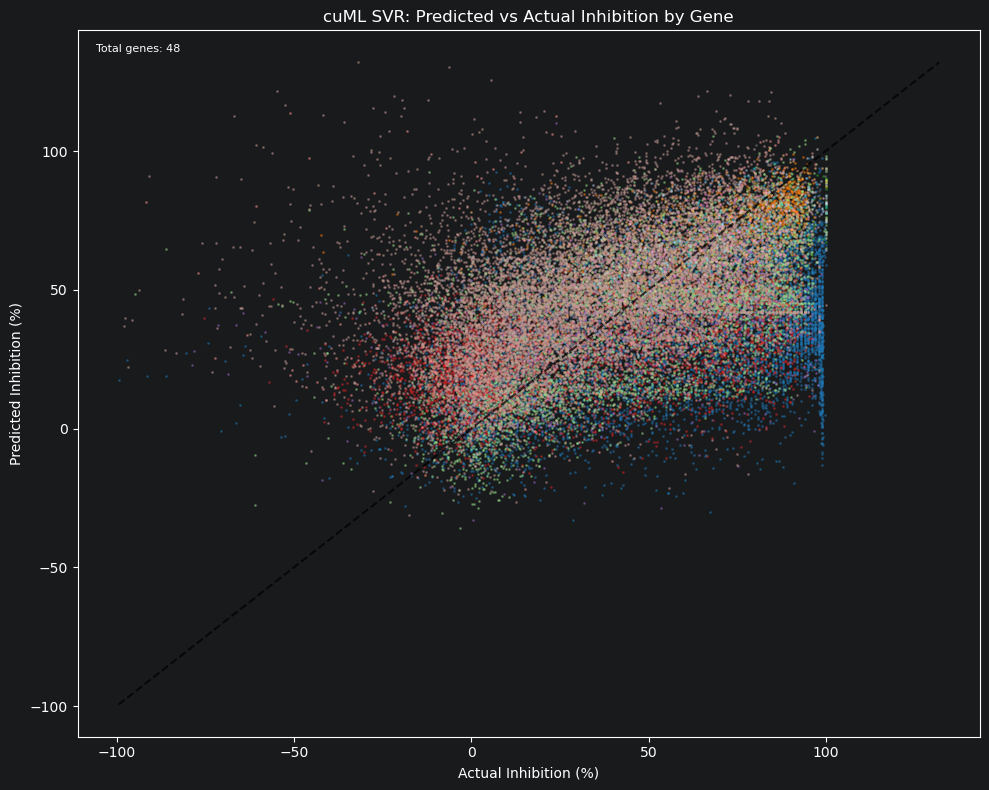

In [14]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

if 'y_true_all' not in locals() or 'y_pred_all' not in locals():
    raise NameError("Data not found! Please run the training loop before plotting.")

unique_genes = np.unique(groups[all_test_idx])
colors = cm.tab20(np.linspace(0, 1, len(unique_genes)))
gene_to_color = dict(zip(unique_genes, colors))

fig, ax = plt.subplots(figsize=(10, 8))

# plot scatter for each gene
for gene in unique_genes:
    mask = groups[all_test_idx] == gene
    ax.scatter(
        y_true_all[mask],
        y_pred_all[mask],
        color=gene_to_color[gene],
        alpha=0.4,
        s=1,
        label=gene,
    )

# diagonal line for perfect predictions
all_vals = np.concatenate([y_true_all, y_pred_all])
lims = [all_vals.min(), all_vals.max()]
ax.plot(lims, lims, "k--", linewidth=1.5, alpha=0.7, label="Perfect prediction")

ax.set_xlabel("Actual Inhibition (%)")
ax.set_ylabel("Predicted Inhibition (%)")
ax.set_title("cuML SVR: Predicted vs Actual Inhibition by Gene")

if len(unique_genes) <= 20:
    ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", markerscale=2, fontsize=7)
else:
    ax.text(0.02, 0.98, f"Total genes: {len(unique_genes)}",
            transform=ax.transAxes, fontsize=8, verticalalignment="top")

plt.tight_layout()
plt.show()

In [18]:
from utils.sequence_encoding import SequenceEncoder

def build_feature_names(enriched_df, target_len=25):
    sugar_names = ["Unmodified", "2'-OMe", "2'-F", "2'-M", "2'-OHe", "2'-P", "Abasic", "2'-F-4'-Thio", "Unknown"]
    acid_names = ["RNA", "DNA", "GNA", "UNA", "LNA", "Unknown"]
    linker_names = ["Normal", "PS", "VP", "Both_VP_PS", "Phosphonate", "Unknown"]

    seq_encoder = SequenceEncoder(enriched_df, target_len=target_len)
    seq_encoder.build_encoding_map()
    seq_names = [k for k, v in sorted(seq_encoder.encoding_map.items(), key=lambda x: x[1])]

    names = ["Concentration_norm", "Time_hours"]

    actual_cell_width = len(enriched_df["Cell_Type_One_Hot"].iloc[0])
    cell_types = sorted(enriched_df["Cell_Type"].dropna().unique())
    cell_type_names = [f"cell_{c}" for c in cell_types]
    if len(cell_type_names) < actual_cell_width:
        cell_type_names += [f"cell_unknown_{i}" for i in range(len(cell_type_names), actual_cell_width)]
    names += cell_type_names[:actual_cell_width]

    for strand in ["Sense", "Antisense"]:
        for pos in range(target_len):
            for base in seq_names:
                names.append(f"{strand}_seq_pos{pos}_{base}")

    for strand in ["Sense", "Antisense"]:
        for pos in range(target_len):
            for acid in acid_names:
                names.append(f"{strand}_acid_pos{pos}_{acid}")
        for pos in range(target_len):
            for sugar in sugar_names:
                names.append(f"{strand}_sugar_pos{pos}_{sugar}")
        for pos in range(target_len):
            for linker in linker_names:
                names.append(f"{strand}_linker_pos{pos}_{linker}")

    for col in ["edit_distance", "target_site_pct"]:
        if col in enriched_df.columns:
            names.append(col)

    return names

feature_names = build_feature_names(enriched_df)
print(f"X columns:            {X.shape[1]}")
print(f"feature_names length: {len(feature_names)}")

X columns:            1425
feature_names length: 1425


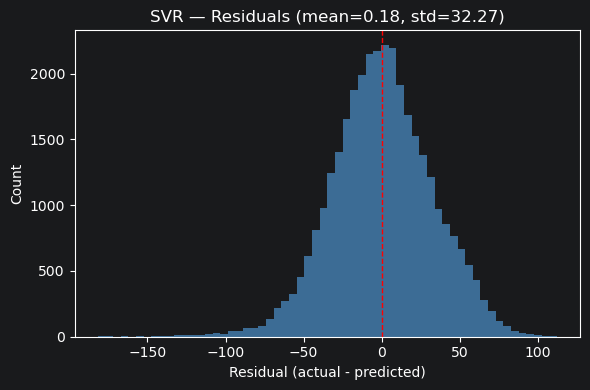

RF proxy Spearman: 0.4682


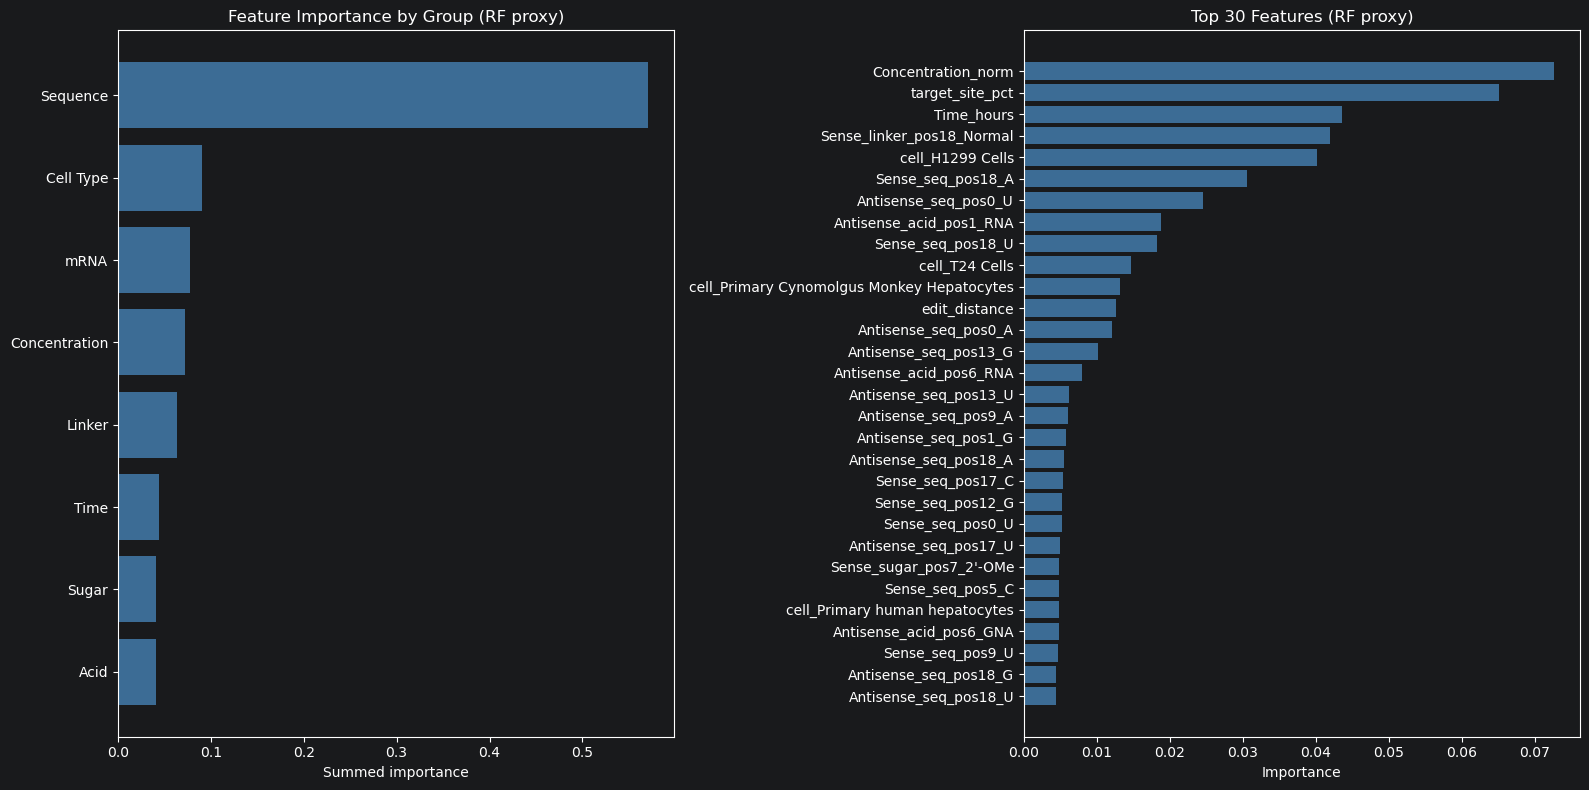

In [19]:
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# residual plot
residuals = y_true_all - y_pred_all
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(residuals, bins=60, color="steelblue", alpha=0.8)
ax.axvline(0, color="red", linestyle="--", lw=1)
ax.set_xlabel("Residual (actual - predicted)")
ax.set_ylabel("Count")
ax.set_title(f"SVR — Residuals (mean={residuals.mean():.2f}, std={residuals.std():.2f})")
plt.tight_layout()
plt.savefig("svr_residuals_cv.png", dpi=150)
plt.show()

# RF feature importance trained on all non-test data
# use last fold's train_idx as a representative training set
train_idx_last = np.setdiff1d(np.arange(len(y)), all_test_idx)

rf = RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=42)
rf.fit(X[train_idx_last], y[train_idx_last])
rf_spearman = spearmanr(rf.predict(X[all_test_idx]), y_true_all)[0]
print(f"RF proxy Spearman: {rf_spearman:.4f}")

importance_df = pd.DataFrame({
    "feature":    feature_names[:X.shape[1]],
    "importance": rf.feature_importances_,
}).sort_values("importance", ascending=False)

def assign_group(name):
    if "sugar"  in name: return "Sugar"
    if "acid"   in name: return "Acid"
    if "linker" in name: return "Linker"
    if "seq"    in name: return "Sequence"
    if "cell_"  in name: return "Cell Type"
    if "Concentration" in name: return "Concentration"
    if "Time"   in name: return "Time"
    if name in ("edit_distance", "target_site_pct"): return "mRNA"
    return "Other"

importance_df["group"] = importance_df["feature"].apply(assign_group)

group_df = (
    importance_df.groupby("group")["importance"]
    .sum()
    .sort_values(ascending=True)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

axes[0].barh(group_df.index, group_df.values, color="steelblue", alpha=0.8)
axes[0].set_xlabel("Summed importance")
axes[0].set_title("Feature Importance by Group (RF proxy)")

top30 = importance_df.head(30)
axes[1].barh(top30["feature"], top30["importance"], color="steelblue", alpha=0.8)
axes[1].invert_yaxis()
axes[1].set_xlabel("Importance")
axes[1].set_title("Top 30 Features (RF proxy)")

plt.tight_layout()
plt.savefig("svr_feature_importance_cv.png", dpi=150)
plt.show()

## Random split

Spearman : 0.7697
Pearson  : 0.7521
RMSE     : 22.0071
MAE      : 16.7522
N test   : 11697


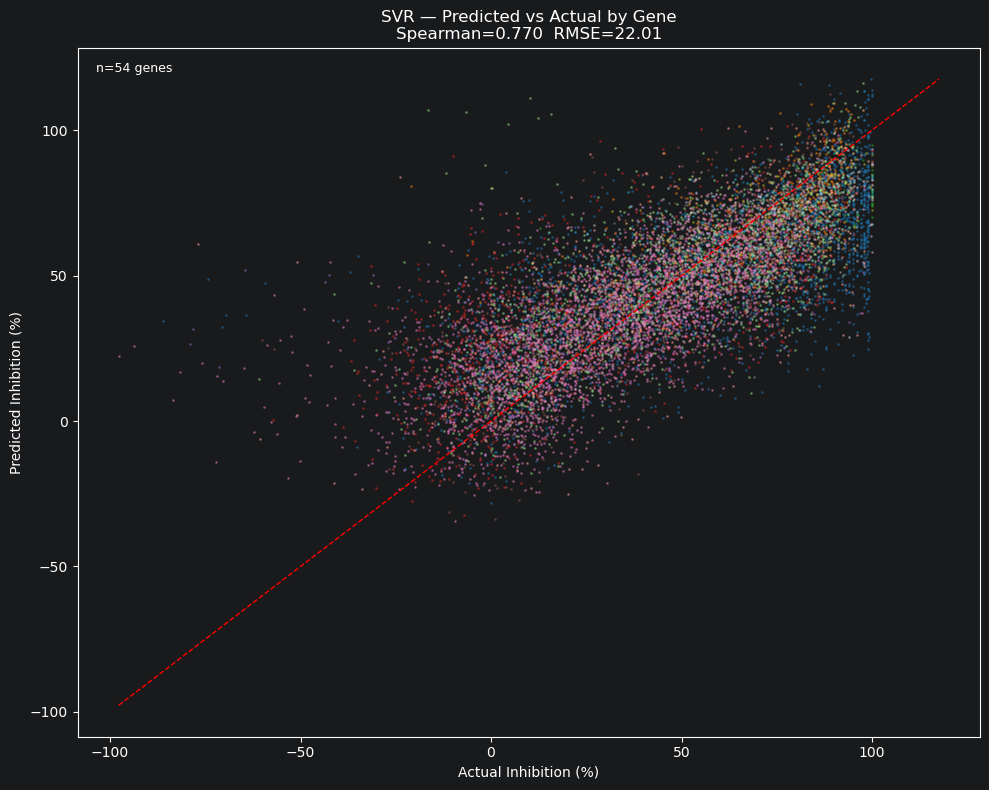

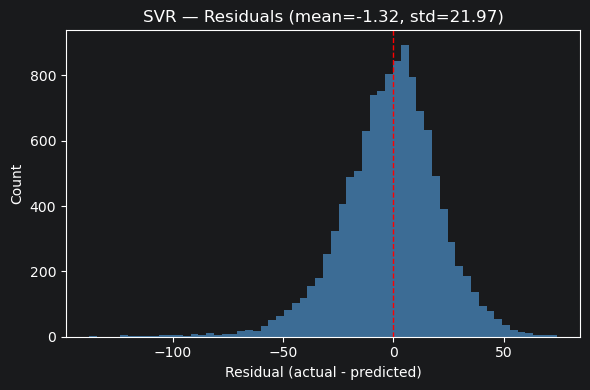

RF proxy Spearman: 0.7956


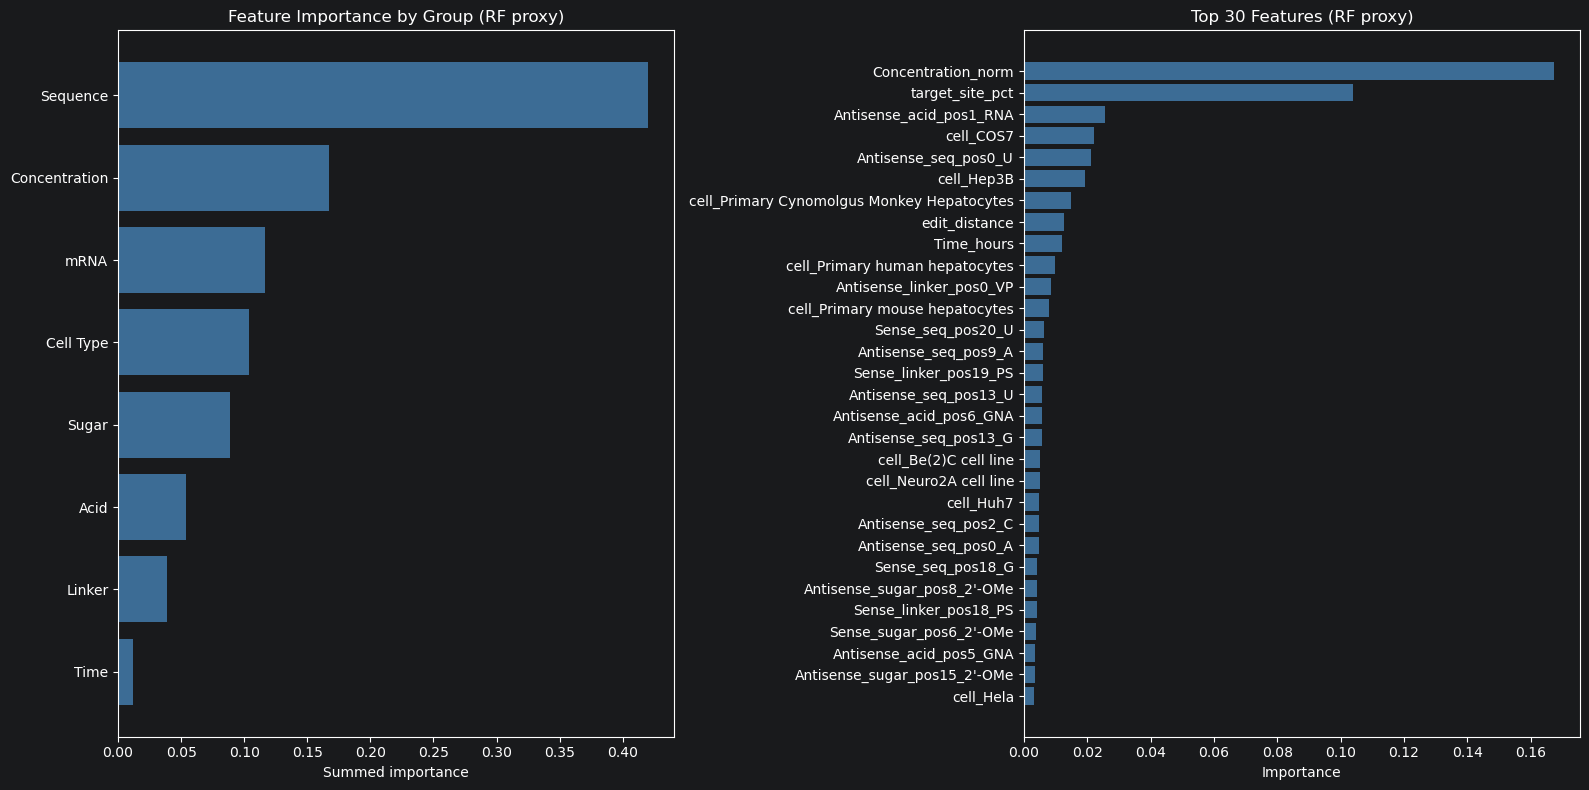

In [21]:
from cuml.svm import SVR
from cuml.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy.stats import spearmanr, pearsonr
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

# split
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.33, random_state=42)

# scale
scaler = StandardScaler()
X_tr_scaled = scaler.fit_transform(X_tr)
X_te_scaled  = scaler.transform(X_te)

# train
model = SVR(kernel="rbf", C=100.0, gamma=0.001, epsilon=0.05)
model.fit(X_tr_scaled, y_tr)
preds = model.predict(X_te_scaled)

# evaluate
s_r = spearmanr(y_te, preds)[0]
p_r = pearsonr(y_te, preds)[0]
rmse = mean_squared_error(y_te, preds) ** 0.5
mae  = mean_absolute_error(y_te, preds)

print(f"Spearman : {s_r:.4f}")
print(f"Pearson  : {p_r:.4f}")
print(f"RMSE     : {rmse:.4f}")
print(f"MAE      : {mae:.4f}")
print(f"N test   : {len(y_te)}")

# scatter plot colored by gene
all_idx = np.arange(len(y))
tr_idx, te_idx = train_test_split(all_idx, test_size=0.33, random_state=42)

import matplotlib.cm as cm
unique_genes = np.unique(groups[te_idx])
colors = cm.tab20(np.linspace(0, 1, len(unique_genes)))
gene_to_color = dict(zip(unique_genes, colors))

fig, ax = plt.subplots(figsize=(10, 8))

for gene in unique_genes:
    mask = groups[te_idx] == gene
    ax.scatter(
        y_te[mask],
        preds[mask],
        color=gene_to_color[gene],
        alpha=0.4,
        s=1,
        label=gene,
    )

lims = [min(y_te.min(), preds.min()), max(y_te.max(), preds.max())]
ax.plot(lims, lims, "r--", lw=1)
ax.set_xlabel("Actual Inhibition (%)")
ax.set_ylabel("Predicted Inhibition (%)")
ax.set_title(f"SVR — Predicted vs Actual by Gene\nSpearman={s_r:.3f}  RMSE={rmse:.2f}")

if len(unique_genes) <= 20:
    ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", markerscale=4, fontsize=7)
else:
    ax.text(0.02, 0.98, f"n={len(unique_genes)} genes",
            transform=ax.transAxes, fontsize=9, verticalalignment="top")

plt.tight_layout()
plt.show()

# residual plot
residuals = y_te - preds
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(residuals, bins=60, color="steelblue", alpha=0.8)
ax.axvline(0, color="red", linestyle="--", lw=1)
ax.set_xlabel("Residual (actual - predicted)")
ax.set_ylabel("Count")
ax.set_title(f"SVR — Residuals (mean={residuals.mean():.2f}, std={residuals.std():.2f})")
plt.tight_layout()
plt.show()

# feature importance via RF
rf = RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=42)
rf.fit(X_tr, y_tr)
rf_spearman = spearmanr(rf.predict(X_te), y_te)[0]
print(f"RF proxy Spearman: {rf_spearman:.4f}")

importance_df = pd.DataFrame({
    "feature":    feature_names[:X.shape[1]],
    "importance": rf.feature_importances_,
}).sort_values("importance", ascending=False)

# grouped importance
def assign_group(name):
    if "sugar"  in name: return "Sugar"
    if "acid"   in name: return "Acid"
    if "linker" in name: return "Linker"
    if "seq"    in name: return "Sequence"
    if "cell_"  in name: return "Cell Type"
    if "Concentration" in name: return "Concentration"
    if "Time"   in name: return "Time"
    if name in ("edit_distance", "target_site_pct"): return "mRNA"
    return "Other"

importance_df["group"] = importance_df["feature"].apply(assign_group)

group_df = (
    importance_df.groupby("group")["importance"]
    .sum()
    .sort_values(ascending=True)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# left: by group
axes[0].barh(group_df.index, group_df.values, color="steelblue", alpha=0.8)
axes[0].set_xlabel("Summed importance")
axes[0].set_title("Feature Importance by Group (RF proxy)")

# right: top 30 individual features
top30 = importance_df.head(30)
axes[1].barh(top30["feature"], top30["importance"], color="steelblue", alpha=0.8)
axes[1].invert_yaxis()
axes[1].set_xlabel("Importance")
axes[1].set_title("Top 30 Features (RF proxy)")

plt.tight_layout()
plt.show()